# EDA completo — N-CMAPSS DS02
### TFM: Arquitectura de Mantenimiento Predictivo con ingesta en tiempo real

Análisis Exploratorio de Datos del subconjunto **DS02** del dataset *Turbofan Engine
Degradation Simulation-2* (N-CMAPSS) de la NASA. DS02 contiene 9 motores con
degradación combinada de **HPT + LPT** (turbinas de alta y baja presión) y es el
subconjunto de referencia para prognosis *data-driven*.

**Estructura del fichero (`.h5`)** — las variables vienen separadas por grupos:

| Grupo | Contenido | Vars | ¿Feature de producción? |
|-------|-----------|------|--------------------------|
| `W`   | Condiciones de vuelo (alt, Mach, TRA, T2) | 4  | Sí |
| `X_s` | Sensores físicos medidos | 14 | Sí |
| `X_v` | Sensores **virtuales** (no observables) | 14 | No (solo análisis) |
| `T`   | Parámetros de salud θ (**ground truth** de degradación) | 10 | No (solo validación) |
| `A`   | Auxiliares: `unit`, `cycle`, `Fc`, `hs` | 4 | — |
| `Y`   | RUL (vida útil restante, en ciclos) | 1 | Objetivo |

`Fc`: clase de vuelo (1=corto, 2=medio, 3=largo). `hs`: estado de salud (1=sano, 0=degradado).
Muestreo a **1 Hz** → millones de filas.

> Objetivo del EDA: entender la flota, la señal de degradación y el efecto de las
> condiciones de vuelo, para fundamentar el *feature engineering* y la arquitectura
> de ingesta en tiempo real antes de entrenar ningún modelo.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

# >>> AJUSTA ESTA RUTA al fichero descargado de la NASA <<<
DATA_PATH = Path("C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS02-006.h5")
OUTPUT_DIR = Path('./eda_outputs'); OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PLOT_DOWNSAMPLE = 100   # 1 de cada N muestras para los scatter pesados
plt.rcParams.update({'figure.figsize': (11, 5), 'axes.grid': True, 'font.size': 10})

## 1. Carga de datos

Cargamos **todos** los grupos (incluidos `X_v` y `T`) porque en el EDA nos interesa
entender la degradación real. En el modelo de producción NO se usarán esos dos grupos.
Usamos `float32` para reducir la memoria a la mitad.

In [2]:
def _decode(h5, key):
    # Los nombres de variable vienen como bytes -> str
    return [v.decode() if isinstance(v, bytes) else str(v)
            for v in np.array(h5.get(key)).ravel()]

def load_ncmapss(filepath, split='dev', dtype=np.float32):
    filepath = Path(filepath)
    if not filepath.exists():
        raise FileNotFoundError(
            f'No encuentro {filepath}. Descarga el .h5 de N-CMAPSS y ajusta DATA_PATH.')
    with h5py.File(filepath, 'r') as f:
        W   = np.asarray(f.get(f'W_{split}'),   dtype=dtype)
        X_s = np.asarray(f.get(f'X_s_{split}'), dtype=dtype)
        X_v = np.asarray(f.get(f'X_v_{split}'), dtype=dtype)
        T   = np.asarray(f.get(f'T_{split}'),   dtype=dtype)
        A   = np.asarray(f.get(f'A_{split}'),   dtype=dtype)
        Y   = np.asarray(f.get(f'Y_{split}'),   dtype=dtype)
        W_var, X_s_var = _decode(f, 'W_var'), _decode(f, 'X_s_var')
        X_v_var, T_var = _decode(f, 'X_v_var'), _decode(f, 'T_var')
        A_var = _decode(f, 'A_var')
    df = pd.DataFrame(np.concatenate([W, X_s, X_v, T, A, Y], axis=1),
                      columns=W_var + X_s_var + X_v_var + T_var + A_var + ['RUL'])
    for c in ['unit', 'cycle', 'Fc', 'hs']:
        df[c] = df[c].astype(int)
    groups = {'W': W_var, 'X_s': X_s_var, 'X_v': X_v_var,
              'T': T_var, 'A': A_var, 'Y': ['RUL']}
    return df, groups

In [3]:
df_dev, groups = load_ncmapss(DATA_PATH, 'dev')
df_test, _ = load_ncmapss(DATA_PATH, 'test')

print('Fichero:', DATA_PATH.name)
print(f'dev  -> {df_dev.shape[0]:,} filas x {df_dev.shape[1]} cols '
      f'({df_dev.memory_usage(deep=True).sum()/1e6:,.0f} MB)')
print(f'test -> {df_test.shape[0]:,} filas x {df_test.shape[1]} cols')
df_dev.head()

Fichero: N-CMAPSS_DS02-006.h5
dev  -> 5,263,447 filas x 47 cols (1,074 MB)
test -> 1,253,743 filas x 47 cols


,alt,Mach,TRA,T2,T24,T30,T48,T50,P15,P2,P21,P24,Ps30,P40,P50,Nf,Nc,Wf,T40,P30,P45,W21,W22,W25,W31,W32,W48,W50,SmFan,SmLPC,SmHPC,phi,fan_eff_mod,fan_flow_mod,LPC_eff_mod,LPC_flow_mod,HPC_eff_mod,HPC_flow_mod,HPT_eff_mod,HPT_flow_mod,LPT_eff_mod,LPT_flow_mod,unit,cycle,Fc,hs,RUL
0,10005.0,0.448497,76.903748,502.420929,600.148010,1438.498169,1818.027710,1228.129883,15.806267,11.577097,16.046970,20.126623,331.293671,336.631836,12.629360,2160.926514,8591.373047,3.855337,2797.727051,352.494049,62.768753,2420.557617,228.486923,228.487061,26.498785,15.899271,215.844849,228.411667,16.648832,9.898130,25.376144,41.893990,0.0,0.0,0.0,0.0,0.0,0.0,-0.000638,0.0,0.0,0.0,2,1,3,1,74.0
1,10013.0,0.447741,76.903748,502.326111,600.055908,1438.350220,1817.682617,1227.879150,15.795477,11.568235,16.036016,20.113218,331.109863,336.446747,12.623033,2160.909424,8590.972656,3.852319,2797.209229,352.300262,62.734718,2418.935059,228.382431,228.383499,26.486551,15.891931,215.745636,228.307007,16.639221,9.904926,25.380548,41.884434,0.0,0.0,0.0,0.0,0.0,0.0,-0.000638,0.0,0.0,0.0,2,1,3,1,74.0
2,10017.0,0.448938,77.079529,502.416077,600.210754,1439.109131,1820.020630,1229.422485,15.807747,11.574866,16.048473,20.130957,331.753174,337.082489,12.637951,2161.819092,8593.032227,3.866201,2800.736328,352.965973,62.851753,2421.245605,228.651138,228.661087,26.519341,15.911604,216.019058,228.592285,16.649822,9.923503,25.318848,41.953850,0.0,0.0,0.0,0.0,0.0,0.0,-0.000638,0.0,0.0,0.0,2,1,3,1,74.0
3,10024.0,0.449883,77.079529,502.469879,600.369690,1439.240234,1819.188354,1228.538696,15.816360,11.578198,16.057219,20.146717,331.819122,337.162842,12.631510,2162.768555,8593.781250,3.863328,2799.352295,353.050079,62.873081,2422.941650,228.786957,228.768631,26.532043,15.919227,216.121231,228.702988,16.653812,9.905518,25.361980,41.914341,0.0,0.0,0.0,0.0,0.0,0.0,-0.000638,0.0,0.0,0.0,2,1,3,1,74.0
4,10031.0,0.449379,77.079529,502.401276,600.298218,1439.063965,1818.963501,1228.389038,15.807512,11.571593,16.048237,20.135889,331.626007,336.966949,12.624871,2162.619629,8593.219727,3.860818,2799.034668,352.844971,62.836601,2421.608887,228.651688,228.653625,26.518459,15.911077,216.008514,228.584793,16.649031,9.897465,25.363995,41.911503,0.0,0.0,0.0,0.0,0.0,0.0,-0.000638,0.0,0.0,0.0,2,1,3,1,74.0


## 2. Estructura y diccionario de variables

In [4]:
print('Grupos de variables:')
for g, c in groups.items():
    print(f'  {g:4s} ({len(c):2d}): {c}')

# Atajos a las listas de columnas
Wc, Xs, Xv, Tc = groups['W'], groups['X_s'], groups['X_v'], groups['T']

Grupos de variables:
  W    ( 4): ['alt', 'Mach', 'TRA', 'T2']
  X_s  (14): ['T24', 'T30', 'T48', 'T50', 'P15', 'P2', 'P21', 'P24', 'Ps30', 'P40', 'P50', 'Nf', 'Nc', 'Wf']
  X_v  (14): ['T40', 'P30', 'P45', 'W21', 'W22', 'W25', 'W31', 'W32', 'W48', 'W50', 'SmFan', 'SmLPC', 'SmHPC', 'phi']
  T    (10): ['fan_eff_mod', 'fan_flow_mod', 'LPC_eff_mod', 'LPC_flow_mod', 'HPC_eff_mod', 'HPC_flow_mod', 'HPT_eff_mod', 'HPT_flow_mod', 'LPT_eff_mod', 'LPT_flow_mod']
  A    ( 4): ['unit', 'cycle', 'Fc', 'hs']
  Y    ( 1): ['RUL']


In [5]:
# Diccionario de las señales físicas (estaciones del motor según doc. CMAPSS)
desc = {
    'alt':'Altitud', 'Mach':'Número de Mach', 'TRA':'Throttle Resolver Angle (acelerador)',
    'T2':'Temp. total entrada del fan',
    'T24':'Temp. salida LPC', 'T30':'Temp. salida HPC', 'T48':'Temp. salida HPT',
    'T50':'Temp. salida LPT', 'P15':'Presión bypass', 'P2':'Presión entrada fan',
    'P21':'Presión salida fan', 'P24':'Presión salida LPC', 'Ps30':'Presión estática salida HPC',
    'P40':'Presión salida burner', 'P50':'Presión salida LPT',
    'Nf':'Velocidad eje lento (fan)', 'Nc':'Velocidad eje rápido (core)', 'Wf':'Flujo de combustible'}
pd.DataFrame({'variable': Wc + Xs,
              'descripcion': [desc.get(v, '-') for v in Wc + Xs]})

,variable,descripcion
0,alt,Altitud
1,Mach,Número de Mach
2,TRA,Throttle Resolver Angle (acelerador)
3,T2,Temp. total entrada del fan
4,T24,Temp. salida LPC
5,T30,Temp. salida HPC
6,T48,Temp. salida HPT
7,T50,Temp. salida LPT
8,P15,Presión bypass
9,P2,Presión entrada fan


## 3. Inventario de la flota

Cuántos motores, cuántos vuelos (ciclos) por motor, qué clase de vuelo opera cada uno
y cuánta vida en horas representa el conjunto.

In [6]:
def inventario(df, nombre):
    print(f'===== {nombre} =====')
    print('Motores:', sorted(df['unit'].unique()), '| nº =', df['unit'].nunique())
    print(f'Muestras: {df.shape[0]:,} (1 Hz) ~ {df.shape[0]/3600:,.0f} h de vuelo')
    ciclos = df.groupby('unit')['cycle'].max()
    print('\nVuelos por motor:'); print(ciclos.to_string())
    print(f'  min={ciclos.min()} max={ciclos.max()} media={ciclos.mean():.1f}')
    fc = df.groupby('unit')['Fc'].agg(lambda s: s.mode().iloc[0])
    print('\nClase de vuelo por motor [1=corto,2=medio,3=largo]:'); print(fc.to_string())
    dur = df.groupby(['Fc','unit','cycle']).size().groupby('Fc').mean()
    print('\nDuración media de vuelo por clase:')
    for c, v in dur.items():
        print(f'  Fc={c}: {v:,.0f} s (~{v/3600:.1f} h)')
    return ciclos, fc

ciclos_dev, fc_dev = inventario(df_dev, 'DESARROLLO (train)')

===== DESARROLLO (train) =====
Motores: [np.int64(2), np.int64(5), np.int64(10), np.int64(16), np.int64(18), np.int64(20)] | nº = 6
Muestras: 5,263,447 (1 Hz) ~ 1,462 h de vuelo

Vuelos por motor:
unit
2     75
5     89
10    82
16    63
18    71
20    66
  min=63 max=89 media=74.3

Clase de vuelo por motor [1=corto,2=medio,3=largo]:
unit
2     3
5     3
10    3
16    3
18    3
20    3

Duración media de vuelo por clase:
  Fc=3: 11,801 s (~3.3 h)


In [7]:
ciclos_test, fc_test = inventario(df_test, 'TEST')

===== TEST =====
Motores: [np.int64(11), np.int64(14), np.int64(15)] | nº = 3
Muestras: 1,253,743 (1 Hz) ~ 348 h de vuelo

Vuelos por motor:
unit
11    59
14    76
15    67
  min=59 max=76 media=67.3

Clase de vuelo por motor [1=corto,2=medio,3=largo]:
unit
11    3
14    1
15    2

Duración media de vuelo por clase:
  Fc=1: 2,063 s (~0.6 h)
  Fc=2: 6,470 s (~1.8 h)
  Fc=3: 11,246 s (~3.1 h)


## 4. Calidad de datos

Antes de analizar nada conviene verificar integridad: valores ausentes, duplicados,
sensores constantes (candidatos a descartar) y coherencia de las etiquetas.

In [8]:
print('NaNs por columna (solo > 0):')
na = df_dev.isna().sum(); print(na[na > 0] if na.any() else '  ninguno')

print('\nFilas duplicadas:', df_dev.duplicated().sum())

# Sensores casi constantes: coeficiente de variación bajo aporta poca información
cv = (df_dev[Xs].std() / (df_dev[Xs].mean().abs() + 1e-9)).sort_values()
print('\nCoef. de variación por sensor (std/|media|):'); print(cv.to_string())

print('\nRango de cada señal física:')
df_dev[Wc + Xs].describe().T[['min','max','mean','std']]

NaNs por columna (solo > 0):
  ninguno

Filas duplicadas: 0

Coef. de variación por sensor (std/|media|):
Nc      0.022384
T24     0.048021
T30     0.049553
T50     0.056091
T48     0.064638
Nf      0.068714
P24     0.191517
P21     0.197255
P15     0.197323
P40     0.209201
Ps30    0.209712
P2      0.213395
P50     0.235760
Wf      0.251077

Rango de cada señal física:


,min,max,mean,std
alt,10001.000000,35033.000000,21901.019531,6284.079102
Mach,0.258048,0.749259,0.623771,0.079370
TRA,23.554520,87.626328,68.547394,14.526810
T2,421.377899,510.814606,475.008820,25.557295
T24,484.197174,616.796570,559.058289,26.846573
T30,1068.822632,1487.274902,1319.334839,65.376808
T48,944.500488,1912.816162,1642.639038,106.176888
T50,690.194763,1284.410034,1105.880615,62.030228
P15,5.917596,16.918859,10.821339,2.135294
P2,4.373175,12.268620,8.240632,1.758506


In [9]:
# Coherencia de etiquetas: el RUL debe decrecer por ciclo y hs pasar de 1 a 0 una vez
print('Comprobaciones de coherencia por motor:')
for u in df_dev['unit'].unique():
    sub = df_dev[df_dev['unit'] == u]
    rul_cyc = sub.groupby('cycle')['RUL'].first()
    hs_cyc = sub.groupby('cycle')['hs'].min()
    mono_rul = (rul_cyc.diff().dropna() <= 0).all()      # RUL no creciente
    onset = hs_cyc[hs_cyc == 0].index.min()              # 1er ciclo degradado
    mono_hs = (hs_cyc.diff().dropna() <= 0).all()         # hs no creciente
    print(f'  unit {u:2d}: RUL_no_creciente={mono_rul} | hs_no_creciente={mono_hs} | '
          f'onset_fallo=ciclo {onset} de {rul_cyc.index.max()}')

Comprobaciones de coherencia por motor:
  unit  2: RUL_no_creciente=True | hs_no_creciente=True | onset_fallo=ciclo 17 de 75
  unit  5: RUL_no_creciente=True | hs_no_creciente=True | onset_fallo=ciclo 17 de 89
  unit 10: RUL_no_creciente=True | hs_no_creciente=True | onset_fallo=ciclo 17 de 82
  unit 16: RUL_no_creciente=True | hs_no_creciente=True | onset_fallo=ciclo 16 de 63
  unit 18: RUL_no_creciente=True | hs_no_creciente=True | onset_fallo=ciclo 17 de 71
  unit 20: RUL_no_creciente=True | hs_no_creciente=True | onset_fallo=ciclo 17 de 66


## 5. Variable objetivo: RUL

El RUL (*Remaining Useful Life*) está en ciclos y es constante dentro de cada vuelo.
Vemos su distribución, su evolución por motor y cuándo arranca la fase degradada (`hs=0`):
**en la fase sana no hay señal de degradación**, lo que limita lo que cualquier modelo
puede predecir ahí.

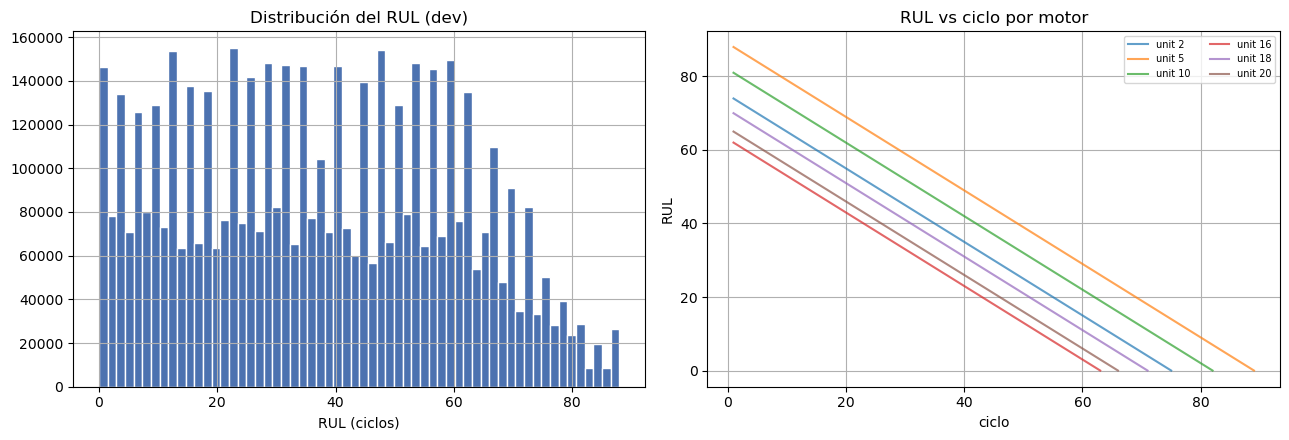

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].hist(df_dev['RUL'], bins=60, color='#4C72B0', edgecolor='white')
ax[0].set_title('Distribución del RUL (dev)'); ax[0].set_xlabel('RUL (ciclos)')
for u in df_dev['unit'].unique():
    s = df_dev[df_dev['unit'] == u].groupby('cycle')['RUL'].first()
    ax[1].plot(s.index, s.values, alpha=0.7, label=f'unit {u}')
ax[1].set_title('RUL vs ciclo por motor'); ax[1].set_xlabel('ciclo'); ax[1].set_ylabel('RUL')
ax[1].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.savefig(OUTPUT_DIR / '05_rul.png', dpi=120); plt.show()

In [11]:
onset = df_dev[df_dev['hs'] == 0].groupby('unit')['cycle'].min()
vida = df_dev.groupby('unit')['cycle'].max()
tabla = pd.DataFrame({'inicio_fallo(hs=0)': onset, 'vida_total': vida})
tabla['%_vida_sano'] = (tabla['inicio_fallo(hs=0)'] / tabla['vida_total'] * 100).round(1)
print('Fase sana vs degradada por motor:'); tabla

Fase sana vs degradada por motor:


,inicio_fallo(hs=0),vida_total,%_vida_sano
unit,,,
2,17,75,22.7
5,17,89,19.1
10,17,82,20.7
16,16,63,25.4
18,17,71,23.9
20,17,66,25.8


## 6. Condiciones operativas (W)

A diferencia del C-MAPSS clásico, N-CMAPSS cubre vuelos completos
(*climb / cruise / descent*). La **envolvente de vuelo** y el perfil temporal muestran
la enorme variabilidad operativa que condiciona las lecturas de los sensores.

          count          mean          std           min           25%           50%           75%           max
alt   5263447.0  21901.019531  6284.079102  10001.000000  16451.000000  22996.000000  27912.000000  35033.000000
Mach  5263447.0      0.623771     0.079370      0.258048      0.566055      0.639009      0.690984      0.749259
TRA   5263447.0     68.547394    14.526810     23.554520     59.413639     74.618607     79.628342     87.626328
T2    5263447.0    475.008820    25.557295    421.377899    460.882095    473.038818    489.370789    510.814606


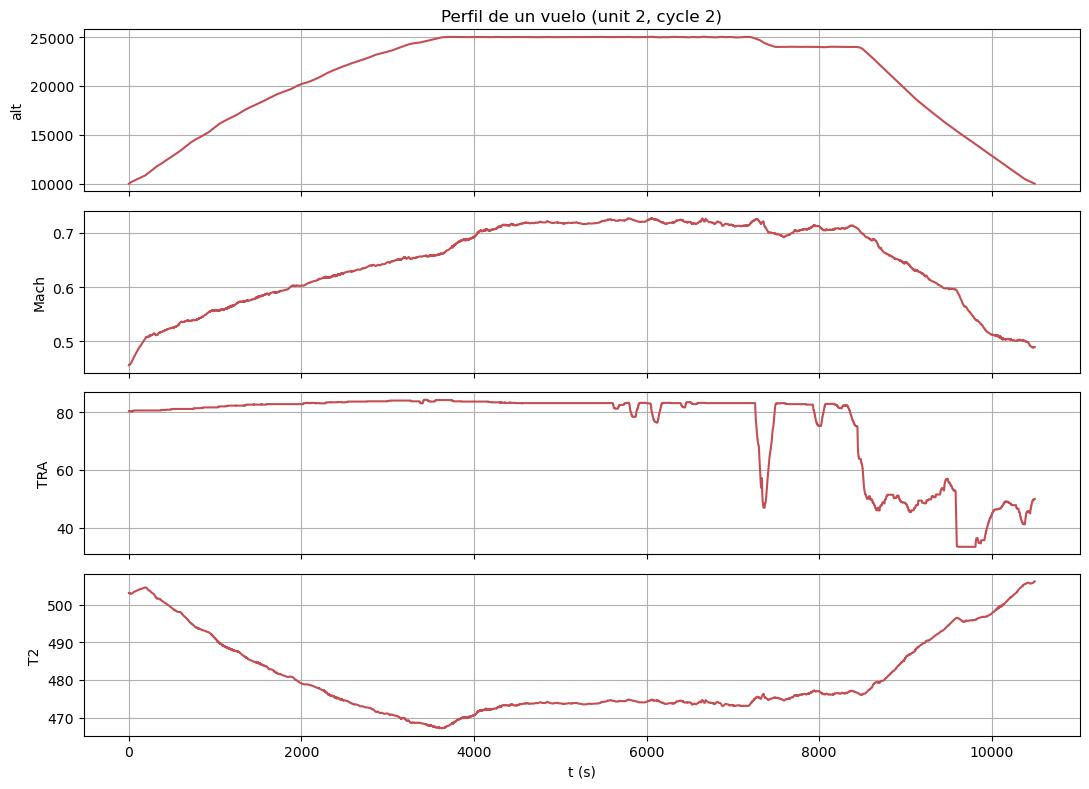

In [12]:
print(df_dev[Wc].describe().T)

# Perfil temporal de un vuelo concreto
u0 = df_dev['unit'].unique()[0]; c0 = 2
vuelo = df_dev[(df_dev['unit'] == u0) & (df_dev['cycle'] == c0)].reset_index(drop=True)
fig, axs = plt.subplots(len(Wc), 1, figsize=(11, 8), sharex=True)
for a, col in zip(axs, Wc):
    a.plot(vuelo.index, vuelo[col], color='#C44E52'); a.set_ylabel(col)
axs[0].set_title(f'Perfil de un vuelo (unit {u0}, cycle {c0})'); axs[-1].set_xlabel('t (s)')
plt.tight_layout(); plt.savefig(OUTPUT_DIR / '06_perfil.png', dpi=120); plt.show()

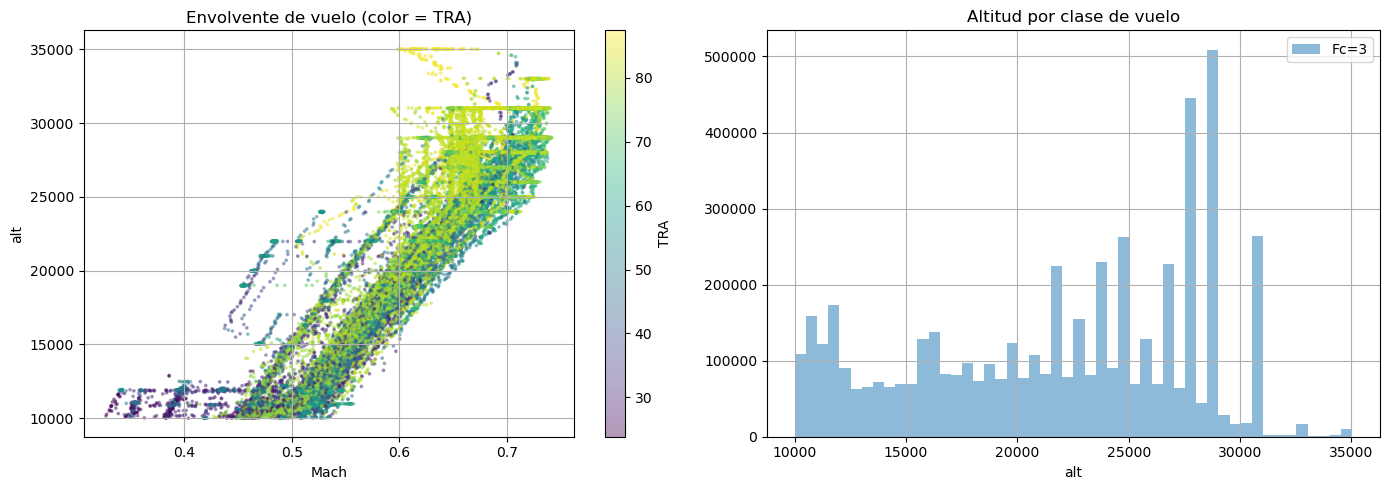

In [13]:
ds = df_dev.iloc[::PLOT_DOWNSAMPLE]
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sc = ax[0].scatter(ds['Mach'], ds['alt'], c=ds['TRA'], s=3, cmap='viridis', alpha=0.4)
plt.colorbar(sc, ax=ax[0], label='TRA'); ax[0].set_xlabel('Mach'); ax[0].set_ylabel('alt')
ax[0].set_title('Envolvente de vuelo (color = TRA)')
for fc in sorted(df_dev['Fc'].unique()):
    ax[1].hist(df_dev[df_dev['Fc'] == fc]['alt'], bins=50, alpha=0.5, label=f'Fc={fc}')
ax[1].set_title('Altitud por clase de vuelo'); ax[1].set_xlabel('alt'); ax[1].legend()
plt.tight_layout(); plt.savefig(OUTPUT_DIR / '06_envolvente.png', dpi=120); plt.show()

## 7. Sensores físicos (X_s)

Los 14 sensores que sí existirían en un motor real. Vemos estadísticos, su
comportamiento dentro de un vuelo y sus distribuciones.

In [14]:
df_dev[Xs].describe().T

,count,mean,std,min,25%,50%,75%,max
T24,5263447.0,559.058289,26.846573,484.197174,546.728210,556.327209,571.105652,616.796570
T30,5263447.0,1319.334839,65.376808,1068.822632,1288.784180,1318.392700,1353.122131,1487.274902
T48,5263447.0,1642.639038,106.176888,944.500488,1594.243042,1652.976318,1700.396790,1912.816162
T50,5263447.0,1105.880615,62.030228,690.194763,1072.944580,1097.635864,1137.344971,1284.410034
P15,5263447.0,10.821339,2.135294,5.917596,9.017441,10.366698,12.505200,16.918859
P2,5263447.0,8.240632,1.758506,4.373175,6.725045,7.832856,9.689625,12.268620
P21,5263447.0,10.986138,2.167068,6.007711,9.154762,10.524567,12.695634,17.176506
P24,5263447.0,13.594254,2.603537,6.914424,11.487061,13.060048,15.451842,21.984966
Ps30,5263447.0,208.181946,43.658211,80.330757,177.726852,197.438721,234.125145,372.484467
P40,5263447.0,211.738571,44.295841,82.093094,180.824272,200.861694,238.119789,378.155884


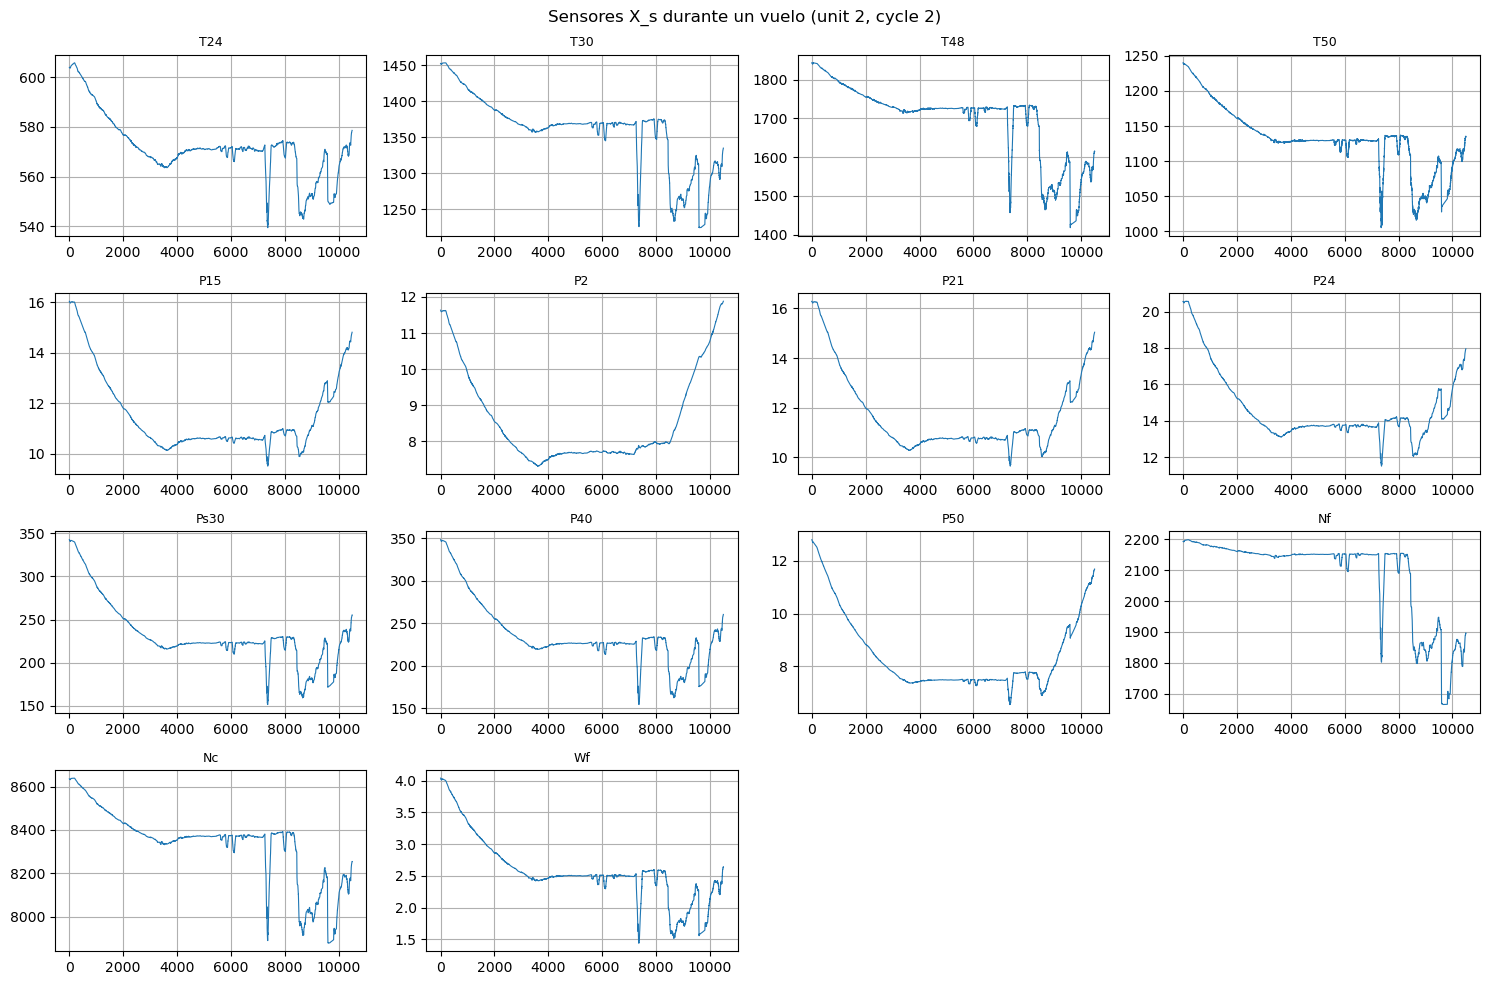

In [15]:
fig, axs = plt.subplots(4, 4, figsize=(15, 10))
for a, col in zip(axs.ravel(), Xs):
    a.plot(vuelo.index, vuelo[col], lw=0.8); a.set_title(col, fontsize=9)
for a in axs.ravel()[len(Xs):]:
    a.axis('off')
fig.suptitle(f'Sensores X_s durante un vuelo (unit {u0}, cycle {c0})')
plt.tight_layout(); plt.savefig(OUTPUT_DIR / '07_sensores_vuelo.png', dpi=120); plt.show()

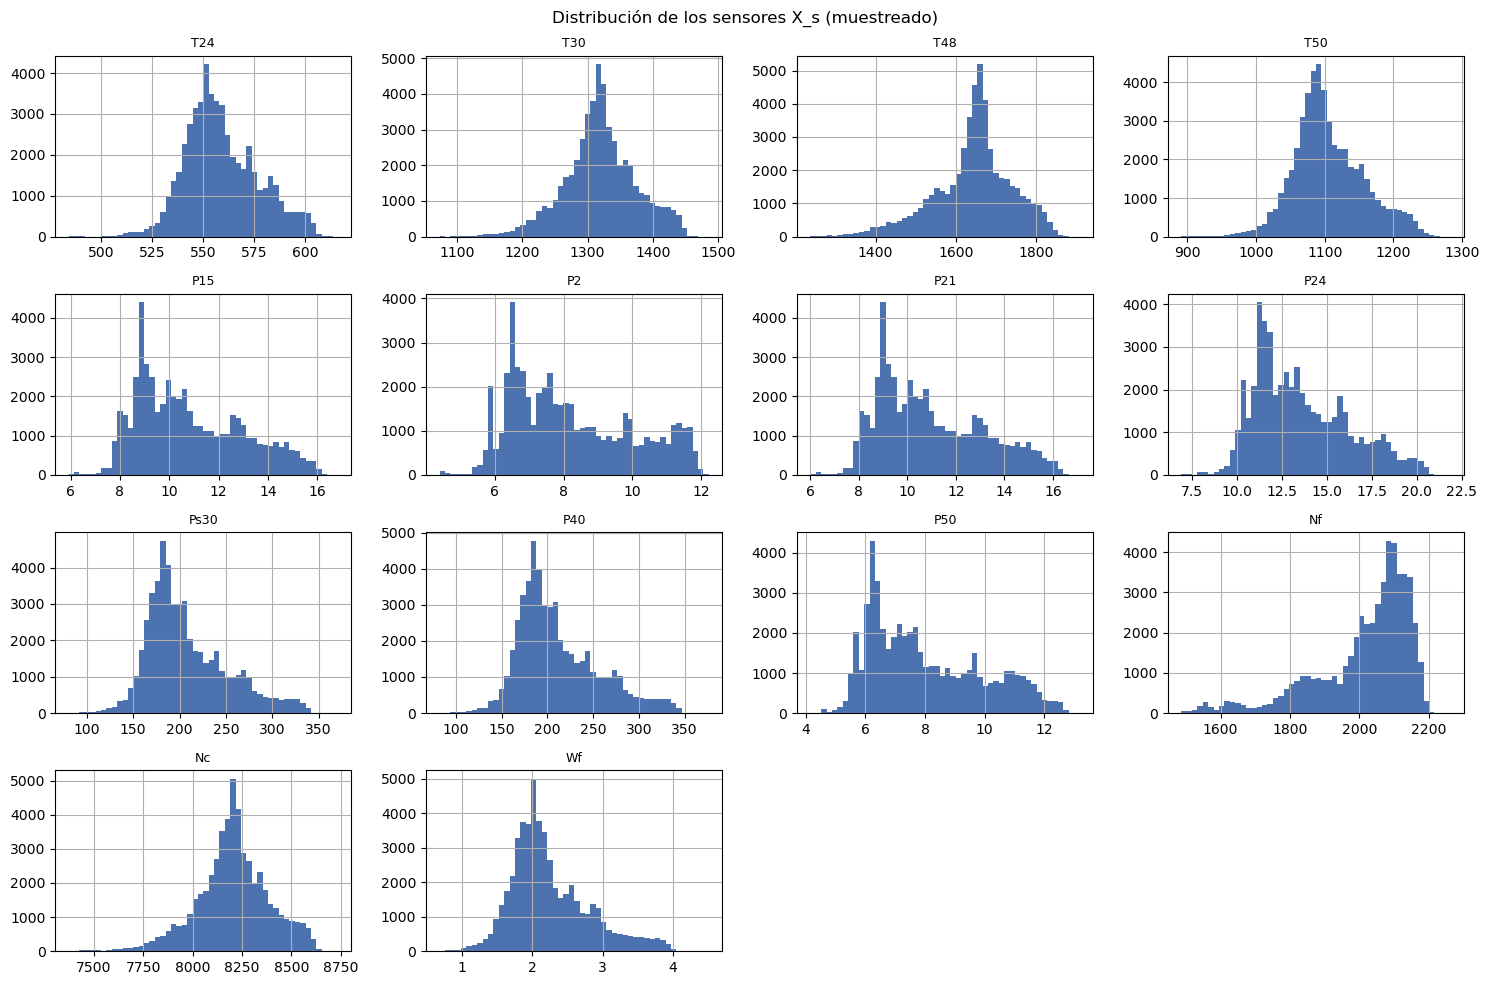

In [16]:
fig, axs = plt.subplots(4, 4, figsize=(15, 10))
for a, col in zip(axs.ravel(), Xs):
    a.hist(ds[col], bins=50, color='#4C72B0'); a.set_title(col, fontsize=9)
for a in axs.ravel()[len(Xs):]:
    a.axis('off')
fig.suptitle('Distribución de los sensores X_s (muestreado)')
plt.tight_layout(); plt.savefig(OUTPUT_DIR / '07_hist_sensores.png', dpi=120); plt.show()

## 8. Señal de degradación

El corazón del EDA. Como las señales dependen mucho de la condición de vuelo, las
resumimos por vuelo (mediana) para comparar "manzanas con manzanas" y ver la **deriva**
de cada sensor a lo largo de la vida del motor. También comparamos directamente los
primeros vuelos (sano) con los últimos (degradado).

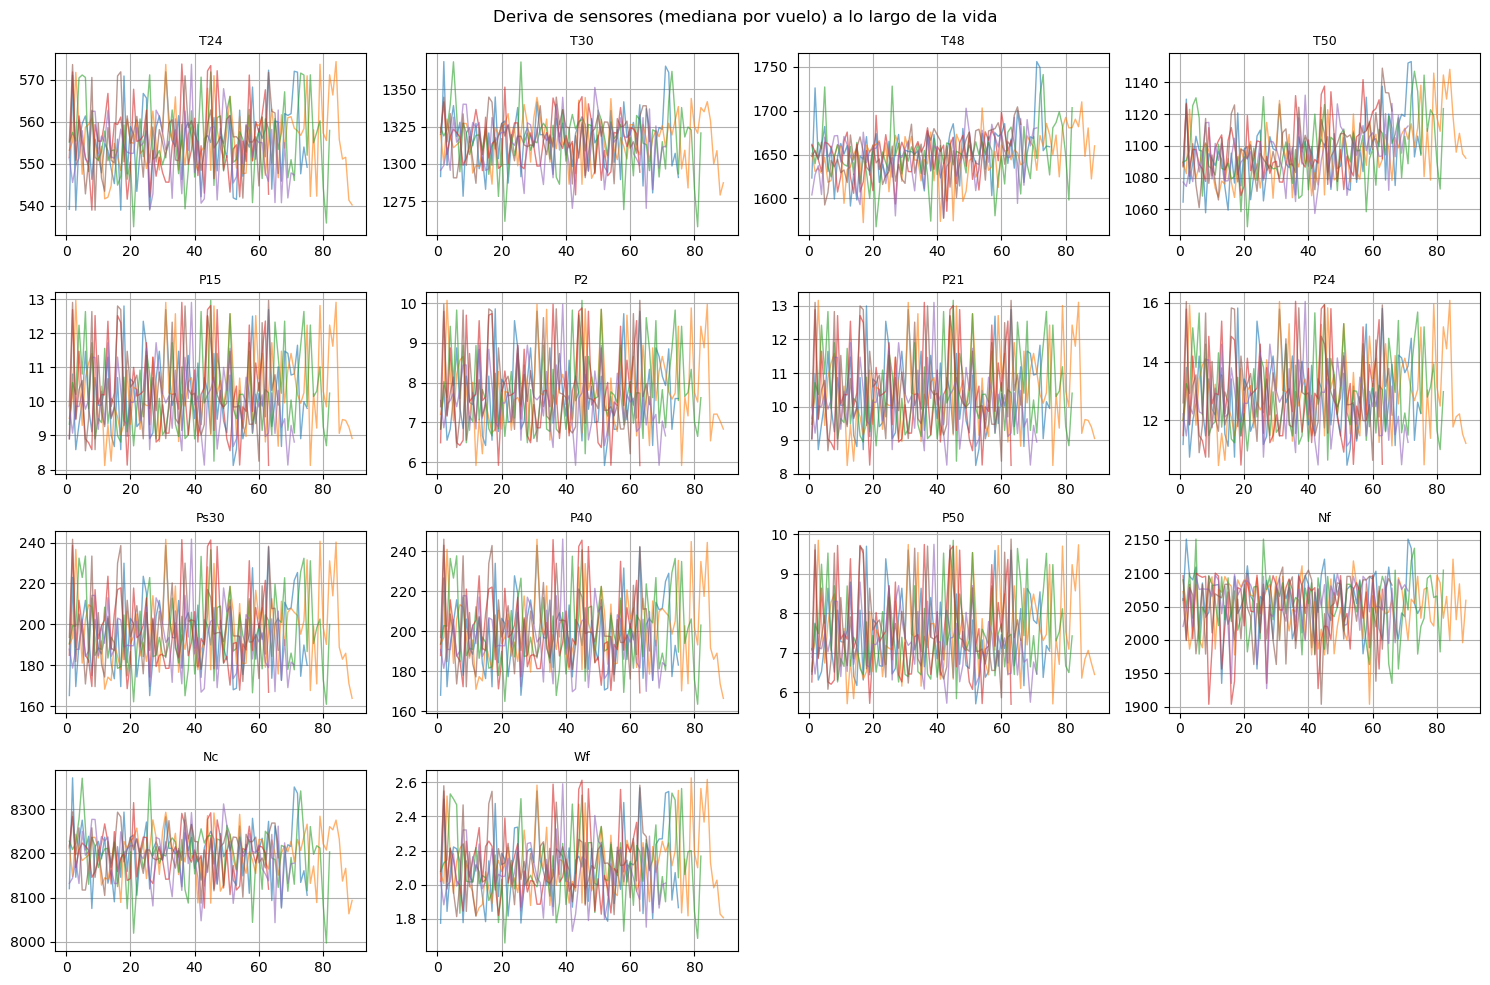

In [17]:
agg = (df_dev.groupby(['unit','cycle'])
       .agg({**{s:'median' for s in Xs}, 'RUL':'mean', 'hs':'min'})
       .reset_index())

fig, axs = plt.subplots(4, 4, figsize=(15, 10))
for a, col in zip(axs.ravel(), Xs):
    for u in agg['unit'].unique():
        s = agg[agg['unit'] == u]
        a.plot(s['cycle'], s[col], alpha=0.6, lw=1)
    a.set_title(col, fontsize=9)
for a in axs.ravel()[len(Xs):]:
    a.axis('off')
fig.suptitle('Deriva de sensores (mediana por vuelo) a lo largo de la vida')
plt.tight_layout(); plt.savefig(OUTPUT_DIR / '08_deriva.png', dpi=120); plt.show()

In [18]:
u0 = agg['unit'].unique()[0]
sub = agg[agg['unit'] == u0]; n = sub['cycle'].max()
sano = sub[sub['cycle'] <= 5]; degr = sub[sub['cycle'] >= n - 5]
comp = pd.DataFrame({'sano(1-5)': sano[Xs].mean(), 'degradado(ult.5)': degr[Xs].mean()})
comp['cambio_%'] = ((comp['degradado(ult.5)'] - comp['sano(1-5)'])
                    / (comp['sano(1-5)'].abs() + 1e-9) * 100).round(2)
print(f'Motor {u0}: sensores sano vs degradado (ordenado por |cambio|):')
comp.reindex(comp['cambio_%'].abs().sort_values(ascending=False).index)

Motor 2: sensores sano vs degradado (ordenado por |cambio|):


,sano(1-5),degradado(ult.5),cambio_%
P2,7.152399,7.826633,9.43
P50,6.854637,7.449103,8.67
P24,12.058712,13.071301,8.40
P21,9.669916,10.478854,8.37
P15,9.524867,10.321671,8.37
Wf,2.083030,2.199574,5.59
Ps30,189.870026,199.863037,5.26
P40,193.009567,203.095474,5.23
T50,1093.163452,1119.724731,2.43
T48,1666.964600,1691.026855,1.44


## 9. Sensores virtuales (X_v) y parámetros de salud (T) (ground truth)

`T` (θ) son los modificadores de eficiencia/flujo que la NASA impuso para simular la
degradación: es la **verdad de campo**, no observable en un motor real. En DS02 degradan
HPT y LPT. Sirven para validar que lo que vemos en los sensores se corresponde con la
degradación real, pero **no se usan como entrada del modelo**.


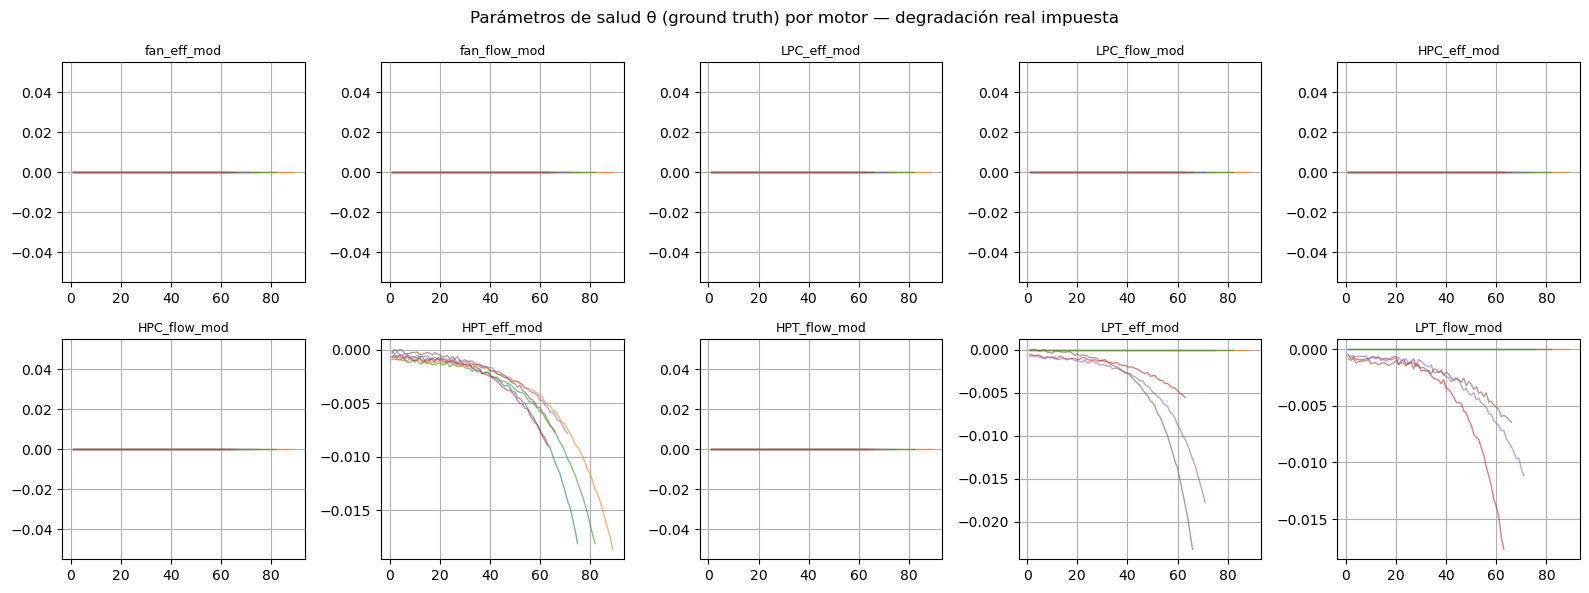

In [19]:
aggT = df_dev.groupby(['unit','cycle'])[Tc].mean().reset_index()
fig, axs = plt.subplots(2, 5, figsize=(16, 6))
for a, col in zip(axs.ravel(), Tc):
    for u in aggT['unit'].unique():
        s = aggT[aggT['unit'] == u]
        a.plot(s['cycle'], s[col], alpha=0.6, lw=1)
    a.set_title(col, fontsize=9)
for a in axs.ravel()[len(Tc):]:
    a.axis('off')
fig.suptitle('Parámetros de salud θ (ground truth) por motor — degradación real impuesta')
plt.tight_layout(); plt.savefig(OUTPUT_DIR / '09_theta.png', dpi=120); plt.show()

## 10. Correlaciones

Entre sensores (detectar redundancias) y de cada sensor con el RUL (qué señales
son más predictivas). Lo hacemos sobre los datos agregados por vuelo.

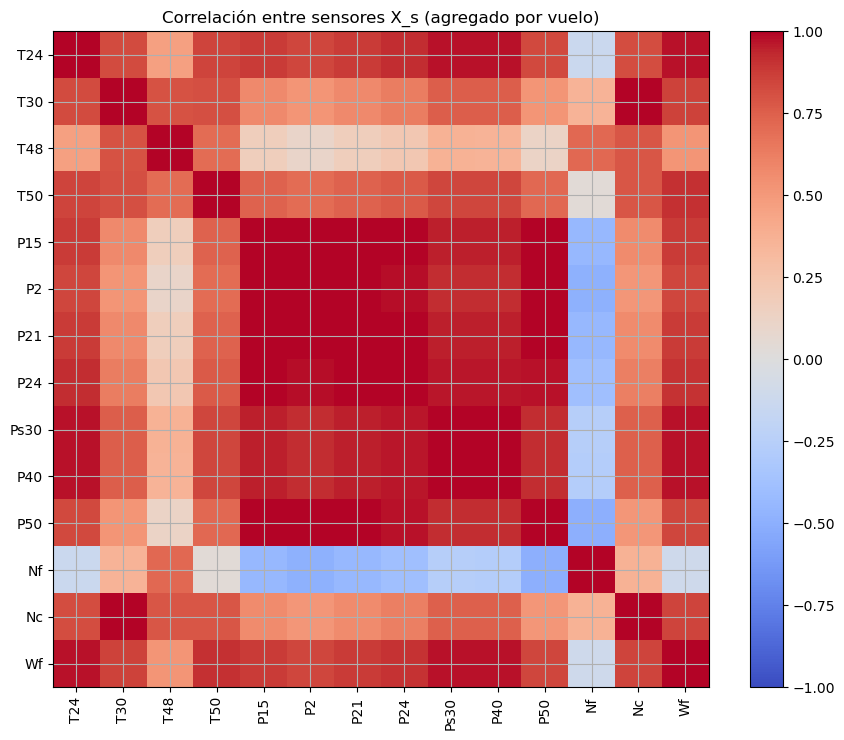

In [20]:
corr = agg[Xs].corr()
plt.figure(figsize=(9, 7.5))
im = plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1); plt.colorbar(im, fraction=0.046)
plt.xticks(range(len(Xs)), Xs, rotation=90); plt.yticks(range(len(Xs)), Xs)
plt.title('Correlación entre sensores X_s (agregado por vuelo)')
plt.tight_layout(); plt.savefig(OUTPUT_DIR / '10_corr_sensores.png', dpi=120); plt.show()

**Conclusión:** los sensores más correlacionados con el RUL son T50 y T48 (temperaturas de
salida de LPT y HPT), justo los dos componentes que DS02 degrada. Que la señal apunte a la
avería real es la mejor garantía de que, si el modelo se apoya en estos sensores, estará
aprendiendo degradación y no un artefacto.

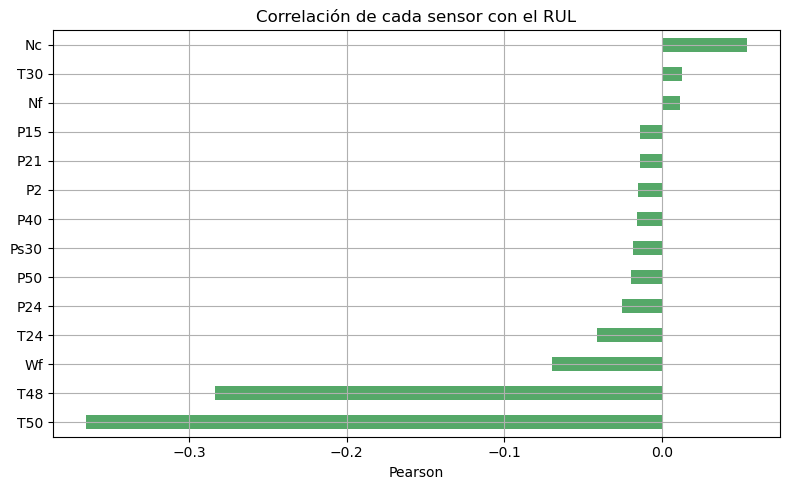

T50    -0.365400
T48    -0.283446
Wf     -0.069506
T24    -0.040903
P24    -0.025442
P50    -0.019863
Ps30   -0.018170
P40    -0.015855
P2     -0.015209
P21    -0.013919
P15    -0.013919
Nf      0.011739
T30     0.012725
Nc      0.054006


In [21]:
corr_rul = agg[Xs + ['RUL']].corr()['RUL'].drop('RUL').sort_values()
plt.figure(figsize=(8, 5))
corr_rul.plot(kind='barh', color='#55A868')
plt.title('Correlación de cada sensor con el RUL'); plt.xlabel('Pearson')
plt.tight_layout(); plt.savefig(OUTPUT_DIR / '10_corr_rul.png', dpi=120); plt.show()
print(corr_rul.to_string())

## 11. Efecto de la condición operativa en los sensores

**Punto clave de N-CMAPSS.** Un mismo sensor varía enormemente según la fase de vuelo,
no solo por la degradación. Esto justifica normalizar por condición operativa o segmentar
por fase (p.ej. crucero), tanto en el *feature engineering* como en la ingesta en tiempo real.

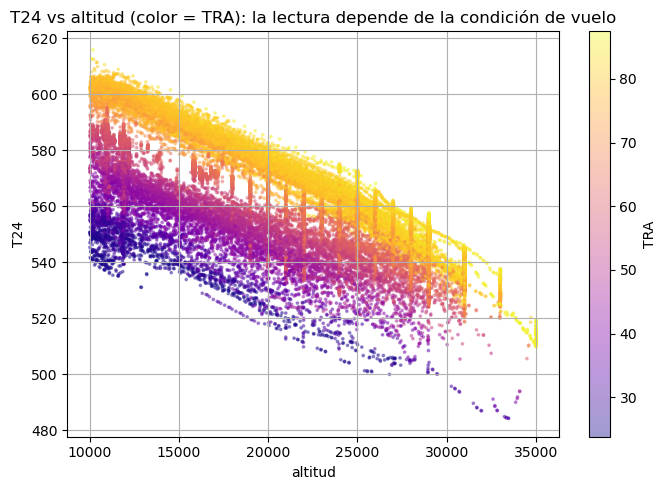

In [22]:
s_demo = Xs[0]
plt.figure(figsize=(7, 5))
sc = plt.scatter(ds['alt'], ds[s_demo], c=ds['TRA'], s=3, cmap='plasma', alpha=0.4)
plt.colorbar(sc, label='TRA'); plt.xlabel('altitud'); plt.ylabel(s_demo)
plt.title(f'{s_demo} vs altitud (color = TRA): la lectura depende de la condición de vuelo')
plt.tight_layout(); plt.savefig(OUTPUT_DIR / '11_sensor_vs_condicion.png', dpi=120); plt.show()

## 12. Conclusiones para el modelado

1. **Granularidad por ciclo.** El RUL es constante dentro del vuelo; agregar cada vuelo a
   estadísticos (media/std/min/max) es la base del baseline y encaja con la ingesta en
   tiempo real (un RUL por vuelo completado).
2. **Features legítimas.** Solo `W` + `X_s` (+ edad del motor). `X_v` y `T` no existen en
   un motor real → se quedan fuera del modelo.
3. **Sensores redundantes/constantes.** Los de coef. de variación bajo y los muy
   correlacionados entre sí pueden reducirse.
4. **Sensores predictivos.** Los de mayor correlación con el RUL guían el *feature
   engineering* del modelo secuencial.
5. **Dependencia de la condición.** Hay que contemplar normalización por condición o
   segmentación por fase de vuelo.
6. **Fase sana sin señal.** Considerar recortar el RUL (cap) para no exigir al modelo
   predecir en la meseta inicial.

**Siguiente paso:** entrenar el baseline (Gradient Boosting sobre features por vuelo) y,
después, el modelo secuencial (LSTM/CNN 1D).

## 13. El cap físico del RUL: ¿cuándo arranca el fallo?

Última pregunta del EDA, y la más importante para el modelado: **¿qué RUL tiene cada motor en el
momento en que arranca su fallo** (transición del indicador de salud `hs` de 1 a 0)? La zona
anterior a ese punto es "vida sana": el RUL decrece pero los sensores aún no expresan degradación,
así que no hay señal que aprender. El valor de RUL en el onset define hasta dónde tiene sentido
pedirle predicciones finas al modelo, y fija el **cap físico** que usaremos en el Baseline.

In [23]:
import h5py, numpy as np, pandas as pd

DATA_PATH = Path("C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS02-006.h5")

with h5py.File(DATA_PATH, 'r') as f:
    A_dev = np.array(f['A_dev'], dtype=np.float32)
    A_var = [v.decode() for v in f['A_var'][:]]

aux = pd.DataFrame(A_dev, columns=A_var)        # aquí sí está hs
for c in ['unit', 'cycle', 'hs']:
    aux[c] = aux[c].astype(int)

# RUL por (unit, cycle): lo sacamos del propio df_dev del baseline
rul_cyc = df_dev.groupby(['unit', 'cycle'])['RUL'].first().reset_index()
# hs por (unit, cycle): un ciclo está "degradado" si algún instante tiene hs=0
hs_cyc = aux.groupby(['unit', 'cycle'])['hs'].min().reset_index()
info = rul_cyc.merge(hs_cyc, on=['unit', 'cycle'])

print('RUL en el onset del fallo (primer ciclo con hs=0), por motor de dev:')
ruls_onset = []
for u in sorted(info.unit.unique()):
    s = info[info.unit == u]
    deg = s[s.hs == 0]
    if deg.empty:
        print(f'  unit {u}: sin ciclos hs=0 (raro, revisar)'); continue
    onset_cycle = deg.cycle.min()
    rul_onset = s.loc[s.cycle == onset_cycle, 'RUL'].iloc[0]
    ruls_onset.append(rul_onset)
    print(f'  unit {u}: vida={s.cycle.max()}, onset=ciclo {onset_cycle}, RUL en onset={rul_onset:.0f}')

print(f'\nRUL en onset -> media={np.mean(ruls_onset):.1f}, '
      f'min={np.min(ruls_onset):.0f}, max={np.max(ruls_onset):.0f}')
print('=> el cap razonable debería rondar ese valor')

RUL en el onset del fallo (primer ciclo con hs=0), por motor de dev:
  unit 2: vida=75, onset=ciclo 17, RUL en onset=58
  unit 5: vida=89, onset=ciclo 17, RUL en onset=72
  unit 10: vida=82, onset=ciclo 17, RUL en onset=65
  unit 16: vida=63, onset=ciclo 16, RUL en onset=47
  unit 18: vida=71, onset=ciclo 17, RUL en onset=54
  unit 20: vida=66, onset=ciclo 17, RUL en onset=49

RUL en onset -> media=57.5, min=47, max=72
=> el cap razonable debería rondar ese valor


**Hallazgo (cap físico):** el fallo arranca (hs pasa de 1 a 0) hacia el ciclo 16–17 en todas
las unidades. El RUL en ese instante de onset va de 47 a 72, con media ≈ 57,5. Interpretación:
por encima de ~57 ciclos de RUL el motor está sano y los sensores no muestran degradación, así
que pedir una predicción exacta ahí solo añadiría ruido. Esto motiva recortar (cap) el objetivo
en torno a 57. **La decisión y validación del cap se hace en el baseline; aquí solo establecemos
el criterio físico que la justifica.**

**Resultado y decisión:** el fallo arranca de media hacia el ciclo 16–17, con un RUL en el onset
de entre 47 y 72 ciclos (media ≈ 57,5). **Fijamos cap = 57 por criterio físico**: por encima de
ese valor el motor está sano y el objetivo no contiene información aprendible.

---

## Conclusiones del EDA (lo que se lleva el modelado)

1. **Sensores más informativos:** T50 y T48 (salidas de LPT y HPT) son los más correlacionados
   con el RUL — coherente con que DS02 degrada precisamente HPT y LPT. Chequeo cruzado pendiente:
   deben aparecer arriba en la importancia de features del modelo.
2. **La condición de vuelo domina la señal:** gran parte de la varianza de los sensores la explica
   la fase de vuelo (altitud, Mach, TRA), no la degradación. Consecuencia: las features deben
   separar régimen operativo de deterioro (medias móviles por ciclo, pendientes).
3. **Cuidado con el split:** el desarrollo de DS02 es 100% clase de vuelo Fc=3, pero el test
   mezcla Fc=1/2/3. Hipótesis a vigilar en el Baseline (spoiler: se refutará).
4. **Variables prohibidas:** X_v (sensores virtuales), T (parámetros de salud) y `hs` no son
   observables en un motor real → quedan fuera del modelo por realismo de despliegue.
5. **Cap físico = 57** (onset del fallo), decidido aquí y mantenido en todo el proyecto.

**Siguiente notebook:** `02_Baseline_XGBoost_DS02` — primer modelo honesto sobre DS02, donde una
fuga de información y un sesgo inesperado nos enseñarán las dos lecciones centrales del proyecto.